# 🧠 Step 5: Bayesian Hidden Markov Model with ADVI (v5)

## What This Notebook Does

Trains a **Bayesian HMM** on the sepsis ICU data to:
1. Discover **3 latent clinical states** (Mild, Moderate, Shock) from 14 observation features
2. Estimate **treatment effects** — how antibiotics, vasopressors, and IV fluids change state transition probabilities
3. Quantify **uncertainty** in all estimates via Bayesian posterior distributions

### v5 Model Design: Free Emission

| Design Choice | Implementation | Why |
|--------------|---------------|-----|
| **Free emission** | `mu = Normal(0, 2, shape=(3, 14))` | Let ALL features define states, not just SOFA. SOFA ordering constraint caused state collapse in earlier versions |
| **Post-hoc labeling** | Sort learned states by SOFA mean | States are named Mild/Moderate/Shock after training, based on which learned state has lowest/highest SOFA |
| **Treatment interaction** | `beta_treat_int × baseline_SOFA` | Treatment effects vary by patient severity (more severe patients may respond differently) |
| **Time in transitions** | `beta_time × delta_t` | Longer gaps between observations → larger transition probabilities (accounts for irregular sampling) |
| **Hourly counterfactual** | `delta_t = 1.0` fixed in simulation | Makes "48-hour prediction" literally mean 48 one-hour steps |

### Model Parameters

| Parameter | Shape | Prior | Role |
|-----------|-------|-------|------|
| `pi` | (3,) | Dirichlet(2, 2, 2) | Initial state distribution |
| `mu` | (3, 14) | Normal(0, 2) | Emission means per state per feature |
| `sigma` | (3, 14) | HalfNormal(1) | Emission standard deviations |
| `logit_base` | (3, 3) | Normal(0, 1) | Baseline transition logits |
| `beta_treat` | (3, 3, 3) | Normal(0, 0.5) | Treatment effects on transitions |
| `beta_treat_int` | (3, 3, 3) | Normal(0, 0.3) | Treatment × SOFA interaction |
| `beta_severity` | (3, 3) | Normal(0, 0.5) | Baseline severity effect |
| `beta_time` | (3, 3) | Normal(0, 0.5) | Time gap effect on transitions |

**Total free parameters**: ~160

### Forward Algorithm (Inference Engine)
The Forward Algorithm computes `P(state_t | observations_1:t)` for every time step.
It processes observations sequentially:
1. Start with initial state distribution `pi`
2. At each time step: (previous state probs × transition matrix) × emission likelihood
3. The transition matrix is dynamically constructed based on current treatment and delta_t

## 📌 Configuration

Set model hyperparameters and file paths. Key tunable: `N_PATIENTS` (200 for testing, 2000 for full run).

In [1]:
import numpy as np
import pandas as pd
import time, os, json, warnings
warnings.filterwarnings("ignore")

import pytensor
pytensor.config.cxx = "/usr/bin/clang++"

import pymc as pm
import arviz as az
import pytensor.tensor as pt
import matplotlib.pyplot as plt

print(f"PyMC:    {pm.__version__}")
print(f"ArviZ:   {az.__version__}")

# =============================================================
# USER CONFIGURATION
# =============================================================
PROJECT_DIR = "/Users/hoon/Documents/10_Classes/12_Bayesian Machine Learning with Generative AI Applications/10_Final_Project"
MODEL_DIR = f"{PROJECT_DIR}/03_Model_Ready_Data"
RESULTS_DIR = f"{PROJECT_DIR}/04_Model_Results"
FIG_DIR = f"{RESULTS_DIR}/ADVI_Figures"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# =============================================================
# TUNABLE
# =============================================================
N_STATES = 3
N_PATIENTS = 2000        # Test first, then 2000
MAX_SEQ_LENGTH = 200
MAX_ADVI_ITER = 50_000
LEARNING_RATE = 0.01
N_POSTERIOR_SAMPLES = 2000
# =============================================================

PyMC:    5.10.4
ArviZ:   0.23.4


## 📌 Data Loading & Subsampling

Loads the model-ready arrays from Step 4 and optionally subsamples patients.

**Stratified subsampling**: When using fewer patients than the full cohort, we preserve
the mortality ratio. If the cohort is 17.2% mortality, the subsample will also be ~17.2%.
This prevents bias in the learned treatment effects.

**Sequence truncation**: Patients with very long sequences (> MAX_SEQ_LENGTH) are truncated.
This bounds the padded tensor size and prevents memory issues. With MAX_SEQ_LENGTH=200 and
median sequence length=170, most patients lose no data.

In [2]:
print("=" * 60)
print("DATA LOADING")
print("=" * 60)

obs_sequences = np.load(f"{MODEL_DIR}/obs_sequences.npy", allow_pickle=True)
int_sequences = np.load(f"{MODEL_DIR}/int_sequences.npy", allow_pickle=True)
seq_lengths = np.load(f"{MODEL_DIR}/seq_lengths.npy")
stay_ids = np.load(f"{MODEL_DIR}/stay_ids.npy")
mortality_labels = np.load(f"{MODEL_DIR}/mortality_labels.npy")
baseline_sofas = np.load(f"{MODEL_DIR}/baseline_sofas.npy")
time_points = np.load(f"{MODEL_DIR}/time_points.npy", allow_pickle=True)

with open(f"{MODEL_DIR}/feature_names.json") as f:
    feature_names = json.load(f)

N_total = len(obs_sequences)
print(f"  Total patients: {N_total:,}")
print(f"  Sequence length: min={seq_lengths.min()}, median={np.median(seq_lengths):.0f}, max={seq_lengths.max()}")

# ⚡ Check delta_t
obs_feat_list = feature_names["obs_features"]
if "delta_t" in obs_feat_list:
    print(f"  ✅ delta_t included in observation features")

# Subsampling (stratified: preserving mortality ratio)
np.random.seed(42)
n_use = min(N_PATIENTS, N_total)
if n_use < N_total:
    mort_idx = np.where(mortality_labels == 1)[0]
    surv_idx = np.where(mortality_labels == 0)[0]
    mort_ratio = len(mort_idx) / N_total
    n_mort = int(n_use * mort_ratio)
    n_surv = n_use - n_mort
    chosen = np.concatenate([
        np.random.choice(mort_idx, min(n_mort, len(mort_idx)), replace=False),
        np.random.choice(surv_idx, min(n_surv, len(surv_idx)), replace=False)
    ])
    np.random.shuffle(chosen)
else:
    chosen = np.arange(N_total)

obs_sub = obs_sequences[chosen]
int_sub = int_sequences[chosen]
lens_sub = seq_lengths[chosen]
sids_sub = stay_ids[chosen]
bsof_sub = baseline_sofas[chosen]
mort_sub = mortality_labels[chosen]
time_sub = time_points[chosen]

# ⚡ Sequence length limit (memory protection!)
# In continuous time, patients may have hundreds to thousands of observations
# Truncate to MAX_SEQ_LENGTH to prevent memory explosion
for i in range(len(obs_sub)):
    if lens_sub[i] > MAX_SEQ_LENGTH:
        obs_sub[i] = obs_sub[i][:MAX_SEQ_LENGTH]
        int_sub[i] = int_sub[i][:MAX_SEQ_LENGTH]
        time_sub[i] = time_sub[i][:MAX_SEQ_LENGTH]
        lens_sub[i] = MAX_SEQ_LENGTH

N = len(obs_sub)
D_obs = obs_sub[0].shape[1]
D_int = int_sub[0].shape[1]

print(f"  Patients used: {N:,} (of total {N/N_total*100:.1f}%)")
print(f"  Obs dimensions: {D_obs}")
print(f"  Treatment dimensions: {D_int}")
print(f"  Sequence length (after truncation): min={lens_sub.min()}, median={np.median(lens_sub):.0f}, max={lens_sub.max()}")
print(f"  Mortality rate: {mort_sub.mean():.1%}")

# Memory estimation
T_max_est = int(lens_sub.max())
mem_gb = (N * T_max_est * (D_obs + D_int + 1) * 4) / (1024**3)
print(f"  ⚡ Estimated padded tensor memory: ~{mem_gb:.2f} GB")
if mem_gb > 4:
    print(f"  ⚠️ Memory risk! Reduce N_PATIENTS or MAX_SEQ_LENGTH")
else:
    print(f"  ✅ Memory OK")


DATA LOADING
  Total patients: 1,502
  Sequence length: min=19, median=170, max=928
  ✅ delta_t included in observation features
  Patients used: 1,502 (of total 100.0%)
  Obs dimensions: 14
  Treatment dimensions: 3
  Sequence length (after truncation): min=19, median=170, max=200
  Mortality rate: 17.2%
  ⚡ Estimated padded tensor memory: ~0.02 GB
  ✅ Memory OK


## 📌 Vectorized Data Preparation

Pads all patient sequences to the same length (`T_max`) so they can be stored in a single
3D tensor. Short sequences are zero-padded, and a binary `mask` tracks which time steps
are real vs. padding. The forward algorithm uses this mask to ignore padded steps.

In [3]:
print("=" * 60)
print("VECTORIZED DATA PREPARATION")
print("=" * 60)

# Pad to max sequence length
T_max = int(lens_sub.max())
print(f"  Max sequence length: {T_max}")
print(f"  Padded tensor shape: ({N}, {T_max}, {D_obs})")

obs_padded = np.zeros((N, T_max, D_obs), dtype=np.float32)
int_padded = np.zeros((N, T_max, D_int), dtype=np.float32)
mask = np.zeros((N, T_max), dtype=np.float32)

for i in range(N):
    T_i = lens_sub[i]
    obs_padded[i, :T_i, :] = obs_sub[i][:T_i]
    int_padded[i, :T_i, :] = int_sub[i][:T_i]
    mask[i, :T_i] = 1.0

# Standardize baseline SOFA
bsof_mean = bsof_sub.mean()
bsof_std = bsof_sub.std() + 1e-6
bsof_scaled = (bsof_sub - bsof_mean) / bsof_std

print(f"  Padded shape: {obs_padded.shape}")
print(f"  Mask coverage: {mask.mean():.1%}")
print(f"  Memory: obs={obs_padded.nbytes/1e6:.0f}MB, int={int_padded.nbytes/1e6:.0f}MB")


VECTORIZED DATA PREPARATION
  Max sequence length: 200
  Padded tensor shape: (1502, 200, 14)
  Padded shape: (1502, 200, 14)
  Mask coverage: 73.3%
  Memory: obs=17MB, int=4MB


## 📌 PyMC Model Construction

**The core of the project.** This cell defines the complete Bayesian HMM in PyMC.

### Emission Model (Free)
Each state k has its own mean vector `mu[k]` (14 features) and std vector `sigma[k]`.
An observation `y_t` has likelihood: `y_t ~ Normal(mu[s_t], sigma[s_t])` where `s_t` is the hidden state.

Unlike previous versions, there is **no ordering constraint** — the model freely discovers
what combination of features defines each state.

### Transition Model (Treatment-Modulated)
The probability of moving from state i to state j depends on:
```
logits[i,j] = logit_base[i,j]                           # baseline transition tendency
             + beta_treat[d,i,j] × treatment[d]          # population treatment effect
             + beta_treat_int[d,i,j] × treatment[d] × SOFA  # patient-specific interaction
             + beta_severity[i,j] × baseline_SOFA        # initial severity adjustment
             + beta_time[i,j] × delta_t                  # time gap effect
```
Then: `P(j|i) = softmax(logits[i,:])`

### Forward Algorithm (Vectorized)
Uses PyTensor's `scan` operation to efficiently process all patients simultaneously.
At each time step t:
1. Compute patient-specific transition matrix from current treatment + delta_t
2. `log_alpha[t] = logsumexp(log_alpha[t-1] + log_trans) + log_emission[t]`
3. Apply mask to ignore padded time steps

In [4]:
print("\n" + "=" * 60)
print("BUILDING PYMC MODEL (v5: free emission)")
print("=" * 60)

obs_features = feature_names['obs_features']
sofa_idx = obs_features.index('sofa_total') if 'sofa_total' in obs_features else -1
delta_t_idx = obs_features.index('delta_t') if 'delta_t' in obs_features else -1
print(f"  SOFA idx={sofa_idx}, delta_t idx={delta_t_idx}")

K = N_STATES

with pm.Model() as hmm_model:
    # ===== PRIORS =====
    pi = pm.Dirichlet('pi', a=np.ones(K) * 2.0)

    # ===== EMISSION: FULLY FREE (no ordering constraint) =====
    # The model discovers states from ALL 14 features jointly
    mu = pm.Normal('mu', mu=0, sigma=2, shape=(K, D_obs))
    sigma = pm.HalfNormal('sigma', sigma=1.0, shape=(K, D_obs))

    # ===== TRANSITION MODEL =====
    logit_base = pm.Normal('logit_base', mu=0, sigma=1, shape=(K, K))
    beta_treat = pm.Normal('beta_treat', mu=0, sigma=0.5, shape=(D_int, K, K))
    beta_treat_int = pm.Normal('beta_treat_int', mu=0, sigma=0.3, shape=(D_int, K, K))
    beta_severity = pm.Normal('beta_severity', mu=0, sigma=0.5, shape=(K, K))
    beta_time = pm.Normal('beta_time', mu=0, sigma=0.5, shape=(K, K))

    # ===== VECTORIZED FORWARD ALGORITHM =====
    obs_tensor = pt.as_tensor_variable(obs_padded)
    int_tensor = pt.as_tensor_variable(int_padded)
    mask_tensor = pt.as_tensor_variable(mask)
    bsof_tensor = pt.as_tensor_variable(bsof_scaled.astype(np.float32))

    # Emission log-likelihood: (N, T_max, K)
    log_emission = pt.zeros((N, T_max, K))
    for k in range(K):
        diff = obs_tensor - mu[k]
        log_em_k = -0.5 * pt.sum(
            pt.log(2 * np.pi * sigma[k]**2) + (diff / sigma[k])**2, axis=2)
        log_emission = pt.set_subtensor(log_emission[:, :, k], log_em_k)

    def forward_step(t, prev_log_alpha, log_emission, int_tensor, obs_tensor,
                     mask_tensor, logit_base, beta_treat, beta_treat_int,
                     beta_severity, beta_time, bsof_tensor):
        logits = logit_base[None, :, :]

        for d in range(D_int):
            treat_d = int_tensor[:, t, d]
            eff = beta_treat[d][None, :, :] + beta_treat_int[d][None, :, :] * bsof_tensor[:, None, None]
            logits = logits + treat_d[:, None, None] * eff

        logits = logits + bsof_tensor[:, None, None] * beta_severity[None, :, :]

        if delta_t_idx >= 0:
            dt = obs_tensor[:, t, delta_t_idx]
            logits = logits + dt[:, None, None] * beta_time[None, :, :]

        log_trans = logits - pt.logsumexp(logits, axis=2, keepdims=True)

        log_alpha_next = pt.logsumexp(
            prev_log_alpha[:, :, None] + log_trans, axis=1
        ) + log_emission[:, t, :]

        m = mask_tensor[:, t][:, None]
        log_alpha_next = m * log_alpha_next + (1 - m) * prev_log_alpha
        return log_alpha_next

    log_alpha_init = pt.log(pi + 1e-10)[None, :] + log_emission[:, 0, :]

    log_alphas, _ = pytensor.scan(
        fn=forward_step,
        sequences=[pt.arange(1, T_max)],
        outputs_info=[log_alpha_init],
        non_sequences=[log_emission, int_tensor, obs_tensor, mask_tensor,
                       logit_base, beta_treat, beta_treat_int,
                       beta_severity, beta_time, bsof_tensor]
    )

    final_log_alpha = log_alphas[-1]
    log_likelihood = pt.logsumexp(final_log_alpha, axis=1)
    pm.Potential('log_likelihood', pt.sum(log_likelihood))

print("Model built! (free emission — no ordering constraint)")
print(f"  States: {K}")
print(f"  D_obs={D_obs}, D_int={D_int}")
print(f"  Emission: mu({K}x{D_obs}) — fully free")


BUILDING PYMC MODEL (v5: free emission)
  SOFA idx=12, delta_t idx=13
Model built! (free emission — no ordering constraint)
  States: 3
  D_obs=14, D_int=3
  Emission: mu(3x14) — fully free


## 📌 ADVI Training

**ADVI** (Automatic Differentiation Variational Inference) approximates the Bayesian posterior.

Instead of sampling (MCMC), it finds a Gaussian approximation to the posterior by minimizing
the KL divergence. This is much faster (hours vs. days) at the cost of some approximation error.

The **ELBO** (Evidence Lower Bound) is the optimization objective — higher is better.
Training converges when ELBO stabilizes.

In [5]:
print("\n" + "=" * 60)
print(f"ADVI FITTING ({N:,} patients, {MAX_ADVI_ITER:,} iterations)")
print("=" * 60)
print(f"  ⏱️ Start: {time.strftime('%H:%M:%S')}")

t0 = time.time()
with hmm_model:
    advi = pm.ADVI()
    tracker = pm.callbacks.Tracker(
        mean=advi.approx.mean.eval,
        std=advi.approx.std.eval
    )
    approx = advi.fit(
        n=MAX_ADVI_ITER,
        callbacks=[tracker],
        obj_optimizer=pm.adam(learning_rate=LEARNING_RATE)
    )
    trace = approx.sample(N_POSTERIOR_SAMPLES)

fit_time = time.time() - t0
print(f"\n✅ ADVI Complete!")
print(f"  Elapsed time: {fit_time/60:.1f}min")


ADVI FITTING (1,502 patients, 50,000 iterations)
  ⏱️ Start: 01:33:13


Finished [100%]: Average Loss = 3.3397e+06



✅ ADVI Complete!
  Elapsed time: 363.9min


## 📌 Convergence Diagnostics

Two checks:
1. **ELBO plot**: Should show rapid initial increase then plateau. Spikes indicate numerical instability.
2. **Effective Sample Size (ESS)**: For variational inference, ESS > 1000 indicates the approximate posterior is well-characterized. R-hat is NaN because we only have 1 chain (ADVI, not MCMC).


CONVERGENCE DIAGNOSTICS


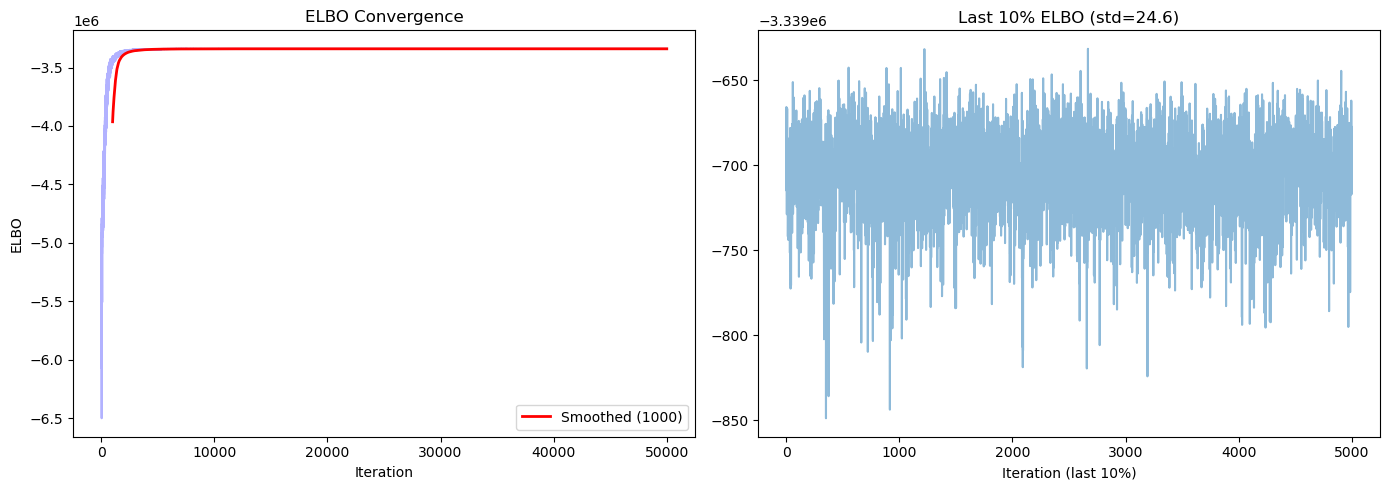

arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)



  ESS range: 1622 - 2123
  R-hat range: nan - nan


In [6]:
print("\n" + "=" * 60)
print("CONVERGENCE DIAGNOSTICS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ELBO trace
elbo = -np.array(approx.hist)
axes[0].plot(elbo, alpha=0.3, color='blue')
# Smoothed
window = min(1000, len(elbo)//10)
if window > 0:
    smooth = pd.Series(elbo).rolling(window).mean()
    axes[0].plot(smooth, color='red', linewidth=2, label=f'Smoothed ({window})')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('ELBO')
axes[0].set_title('ELBO Convergence')
axes[0].legend()

# Check stability of latter portion
last_10pct = elbo[int(len(elbo)*0.9):]
elbo_std = np.std(last_10pct)
axes[1].plot(last_10pct, alpha=0.5)
axes[1].set_title(f'Last 10% ELBO (std={elbo_std:.1f})')
axes[1].set_xlabel('Iteration (last 10%)')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_elbo_convergence.png", dpi=150, bbox_inches='tight')
plt.show()

# Compute ESS
summary = az.summary(trace, var_names=['beta_treat', 'pi'])
print(f"\n  ESS range: {summary['ess_bulk'].min():.0f} - {summary['ess_bulk'].max():.0f}")
print(f"  R-hat range: {summary['r_hat'].min():.3f} - {summary['r_hat'].max():.3f}")

## 📌 Results: Treatment Effects

The key clinical output. For each treatment:
- **Recovery tendency**: Sum of `beta_treat[d, i, j]` where j < i (transitions to less severe states)
- **Worsening tendency**: Sum of `beta_treat[d, i, j]` where j > i (transitions to more severe states)

**Negative worsening = protective effect** (reduces probability of getting worse).
**Positive worsening = apparent harm** (but may be confounded for vasopressors).

### Post-hoc State Ordering
Since emission is free (no constraint), learned state indices are arbitrary.
We sort states by their learned SOFA mean to assign clinical names:
lowest SOFA → "Mild", middle → "Moderate", highest → "Shock".

In [7]:
print("\n" + "=" * 60)
print("TREATMENT EFFECT ESTIMATES")
print("=" * 60)

int_features = feature_names.get('int_features', ['on_antibiotics', 'on_vasopressors', 'on_iv_fluids'])
beta_mean = trace.posterior['beta_treat'].values.mean(axis=(0,1))
beta_int_mean = trace.posterior['beta_treat_int'].values.mean(axis=(0,1))
beta_time_mean = trace.posterior['beta_time'].values.mean(axis=(0,1))

# Post-hoc state ordering by SOFA means
mu_mean = trace.posterior['mu'].values.mean(axis=(0,1))  # (K, D_obs)
sofa_means = mu_mean[:, sofa_idx] if sofa_idx >= 0 else mu_mean[:, 0]
state_order = np.argsort(sofa_means)  # lowest SOFA first
state_names = ['Mild', 'Moderate', 'Shock']

print(f"\n  Post-hoc state ordering (by SOFA mean):")
for rank, idx in enumerate(state_order):
    print(f"    {state_names[rank]} = learned state {idx} (SOFA mean={sofa_means[idx]:.2f})")

# Reorder beta_mean for display
print("\n  Population-level effects (beta_treat):")
for d in range(D_int):
    name = int_features[d] if d < len(int_features) else f'Treatment {d}'
    recovery = sum(beta_mean[d, i, j] for i in range(K) for j in range(K) if j < i)
    worsening = sum(beta_mean[d, i, j] for i in range(K) for j in range(K) if j > i)
    print(f"    [{name}]  Recovery: {recovery:+.3f}  Worsening: {worsening:+.3f}")

print("\n  Interaction with baseline SOFA (beta_treat_int):")
for d in range(D_int):
    name = int_features[d] if d < len(int_features) else f'Treatment {d}'
    int_recovery = sum(beta_int_mean[d, i, j] for i in range(K) for j in range(K) if j < i)
    int_worsening = sum(beta_int_mean[d, i, j] for i in range(K) for j in range(K) if j > i)
    print(f"    [{name}]  Recovery: {int_recovery:+.3f}  Worsening: {int_worsening:+.3f}")

print(f"\n  Time effect (beta_time): norm={np.linalg.norm(beta_time_mean):.3f}")


TREATMENT EFFECT ESTIMATES

  Post-hoc state ordering (by SOFA mean):
    Mild = learned state 0 (SOFA mean=-0.61)
    Moderate = learned state 1 (SOFA mean=0.20)
    Shock = learned state 2 (SOFA mean=1.32)

  Population-level effects (beta_treat):
    [on_antibiotics]  Recovery: -0.276  Worsening: -0.821
    [on_vasopressors]  Recovery: -0.879  Worsening: +1.442
    [on_iv_fluids]  Recovery: +0.406  Worsening: -0.875

  Interaction with baseline SOFA (beta_treat_int):
    [on_antibiotics]  Recovery: +0.082  Worsening: -0.047
    [on_vasopressors]  Recovery: -0.097  Worsening: +0.003
    [on_iv_fluids]  Recovery: -0.049  Worsening: +0.072

  Time effect (beta_time): norm=0.548


## 📌 Emission Parameters (State Profiles)

Shows what the model learned each state "looks like" across all 14 features.
This is the **multi-organ failure profile** — the key advantage of free emission.

The "Key state differences" section highlights which features most strongly
distinguish Mild from Shock states. Clinically meaningful differences should include:
lactate (tissue perfusion), creatinine (kidneys), bilirubin (liver), platelets (coagulation).

In [8]:
print("\n" + "=" * 60)
print("EMISSION PARAMETERS (State Profiles)")
print("=" * 60)

mu_mean = trace.posterior['mu'].values.mean(axis=(0,1))  # (K, D_obs)
sigma_mean = trace.posterior['sigma'].values.mean(axis=(0,1))  # (K, D_obs)
obs_features = feature_names['obs_features']

# Sort states by SOFA
sofa_means = mu_mean[:, sofa_idx] if sofa_idx >= 0 else mu_mean[:, 0]
state_order = np.argsort(sofa_means)

print(f"\n  {'Feature':<15s}", end="")
for rank in range(K):
    print(f"  {state_names[rank]:>12s}", end="")
print()
print("  " + "-" * (15 + 14 * K))

for f_idx, feat in enumerate(obs_features):
    print(f"  {feat:<15s}", end="")
    for rank in range(K):
        s = state_order[rank]
        print(f"  {mu_mean[s, f_idx]:>11.2f}", end="")
    print()

# Key differentiating features
print(f"\n  Key state differences (|Mild - Shock| > 0.5):")
mild_idx = state_order[0]
shock_idx = state_order[-1]
diffs = []
for f_idx, feat in enumerate(obs_features):
    diff = abs(mu_mean[shock_idx, f_idx] - mu_mean[mild_idx, f_idx])
    if diff > 0.5:
        diffs.append((feat, diff, mu_mean[mild_idx, f_idx], mu_mean[shock_idx, f_idx]))
diffs.sort(key=lambda x: -x[1])
for feat, diff, mild_val, shock_val in diffs:
    print(f"    {feat}: Mild={mild_val:.2f} → Shock={shock_val:.2f} (gap={diff:.2f})")


EMISSION PARAMETERS (State Profiles)

  Feature                  Mild      Moderate         Shock
  ---------------------------------------------------------
  heart_rate             -0.03         0.08         0.06
  sbp                     0.13        -0.13        -0.36
  map                     0.12        -0.10        -0.34
  temperature             0.12         0.03        -0.32
  resp_rate              -0.06        -0.00         0.05
  spo2                    0.08         0.09        -0.19
  lactate                -0.32         0.06         0.95
  wbc                    -0.19         0.19         0.19
  platelets               0.24        -0.13        -0.61
  creatinine             -0.42         0.02         0.99
  bilirubin              -0.31        -0.23         1.09
  hemoglobin              0.09         0.16        -0.17
  sofa_total             -0.61         0.20         1.32
  delta_t                 0.01        -0.03        -0.05

  Key state differences (|Mild - Shock| > 

## 📌 Counterfactual Analysis (48h, Hourly Steps)

Simulates "what happens if we apply this treatment for 48 hours?"

Starting from the average initial state distribution (`pi`), we repeatedly apply
the transition matrix for 48 steps. Each step uses `delta_t = 1.0` (one hour),
making the simulation directly interpretable as hourly progression.

**Important**: These are population-average counterfactuals. Individual patient
predictions (which account for their specific observation history) are in Step 6.

In [9]:
print("\n" + "=" * 60)
print("COUNTERFACTUAL ANALYSIS (48h, hourly steps)")
print("=" * 60)

from scipy.special import softmax as sp_softmax

pi_mean = trace.posterior['pi'].values.mean(axis=(0,1))
logit_base_mean = trace.posterior['logit_base'].values.mean(axis=(0,1))
beta_treat_mean_cf = trace.posterior['beta_treat'].values.mean(axis=(0,1))
beta_time_mean_cf = trace.posterior['beta_time'].values.mean(axis=(0,1))

def simulate_hourly(treatment_scenario, n_hours=48):
    state_probs = pi_mean.copy()
    for t in range(n_hours):
        logits = logit_base_mean.copy()
        for d in range(D_int):
            logits += treatment_scenario[d] * beta_treat_mean_cf[d]
        logits += 1.0 * beta_time_mean_cf
        trans = sp_softmax(logits, axis=1)
        state_probs = state_probs @ trans
    return state_probs

scenarios = {
    'No treatment':     [0, 0, 0],
    'Antibiotics only': [1, 0, 0],
    'Abx + IV fluids':  [1, 0, 1],
    'Full treatment':   [1, 1, 1],
}

# Display with post-hoc ordered state names
header = f"  {'Scenario':<25s}" + "".join(f'{state_names[r]:>10s}' for r in range(K))
print(header)
print("  " + "-" * (25 + 10 * K))
for name, scenario in scenarios.items():
    probs_raw = simulate_hourly(scenario[:D_int])
    # Reorder to match state_names
    probs_ordered = [probs_raw[state_order[r]] for r in range(K)]
    row = f"  {name:<25s}" + "".join(f'{p:>9.1%}' for p in probs_ordered)
    print(row)

print("\n  Note: Each step = 1 hour (delta_t=1.0)")
print(f"  States ordered post-hoc by SOFA mean: {[int(s) for s in state_order]}")


COUNTERFACTUAL ANALYSIS (48h, hourly steps)
  Scenario                       Mild  Moderate     Shock
  -------------------------------------------------------
  No treatment                 55.0%    26.7%    18.3%
  Antibiotics only             76.5%    15.6%     7.8%
  Abx + IV fluids              85.8%    10.3%     3.8%
  Full treatment               57.0%    32.9%    10.1%

  Note: Each step = 1 hour (delta_t=1.0)
  States ordered post-hoc by SOFA mean: [0, 1, 2]


## 📌 Save Results

Save the trained model (trace) and summary results. The `state_order` mapping is critical for Step 6 — it tells the DSS which learned state index corresponds to Mild/Moderate/Shock.

In [10]:
print("\n" + "=" * 60)
print("SAVING RESULTS")
print("=" * 60)

trace.to_netcdf(f"{RESULTS_DIR}/hmm_advi_v5_trace_full.nc")
print(f"  Trace: {RESULTS_DIR}/hmm_advi_v5_trace_full.nc")

results = {
    'n_patients': int(N),
    'n_states': K,
    'advi_iterations': MAX_ADVI_ITER,
    'fit_time_minutes': round(fit_time/60, 1),
    'pi_mean': pi_mean.tolist(),
    'beta_treat_mean': beta_mean.tolist(),
    'state_names': state_names,
    'state_order': state_order.tolist(),  # maps rank -> learned state index
    'feature_names': feature_names,
}
with open(f"{RESULTS_DIR}/hmm_results.json", 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nDone! {fit_time/60:.1f}min")
print(f"  state_order: {state_order.tolist()} (Mild, Moderate, Shock)")


SAVING RESULTS
  Trace: /Users/hoon/Documents/10_Classes/12_Bayesian Machine Learning with Generative AI Applications/10_Final_Project/04_Model_Results/hmm_advi_v5_trace_full.nc

Done! 363.9min
  state_order: [0, 1, 2] (Mild, Moderate, Shock)
